## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------


# Physical Constants and Parameters
M1 = 1.0
M2 = 1.0

w1 = 1.0          # Natural frequency of oscillator 1 (rad/s)
w2 = 1.0          # Natural frequency of oscillator 2 (rad/s)

wp1 = 2*(w1+0.0)  # Driving frequency for oscillator 1 (rad/s)
wp2 = 2*(w2+0.0)  # Driving frequency for oscillator 2 (rad/s)

period1 = 2*jnp.pi/w1
period2 = 2*jnp.pi/w2

Fp1 = 0.1        # Amplitude of the wp driving for oscillator 1
Fp2 = 0.0         # Amplitude of the wp driving for oscillator 2

Q1 = 100.0       # Quality factor for oscillator 1
Q2 = 100.0       # Quality factor for oscillator 2

GAMMA1 = w1/(2*Q1)
GAMMA2 = w2/(2*Q2)

gamma1 = 0.01    # Nonlinearity coefficient for oscillator 1 (Duffing term)
gamma2 = 0.00    # Nonlinearity coefficient for oscillator 2 (Duffing term)

c = .01


k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .3             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 5000# Start time
period = 2*jnp.pi/w1
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
x0 = jnp.array([-1.0, -1.0])               # Initial displacement for both oscillators
v0 = jnp.array([0.0, 0.0])               # Initial velocity for both oscillators
y0_x = jnp.concatenate([x0, v0])         # Combined state vector [x1, x2, v1, v2]


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian_coupled(Q1, P1, Q2, P2):
    dw = wp1/2 - w1  # detuning term
    
    # Single oscillator terms (for both oscillators)
    H1 = 3*gamma1/(16*wp1) * (Q1**2 + P1**2)**2 + dw/2 *(Q1**2 - P1**2) + Fp1/(4*M1*wp1) * (P1**2 - Q1**2)
    H2 = 3*gamma2/(16*wp2) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp2/(4*M2*wp2) * (P2**2 - Q2**2)

    # Coupling term
    H_coupling = c/4 * ((Q1 - Q2)**2 + (P1 - P2)**2)
    
    return H1 + H2 + H_coupling


In [4]:
# Plot the Hamiltonian for second oscillator with fixed Q1, P1
Q_range = jnp.linspace(-2, 2, 100)
P_range = jnp.linspace(-2, 2, 100)
# Create meshgrid for Q2 and P2
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Fix values for first oscillator
Q1_fixed = -1.0  # You can adjust these values
P1_fixed = 0.0

# Vectorize Hamiltonian_coupled over Q2 and P2 meshgrids with fixed Q1, P1
H_values = jax.vmap(lambda q2, p2: jax.vmap(
    lambda q2i, p2i: Hamiltonian_coupled(Q1_fixed, P1_fixed, q2i, p2i)
)(q2, p2))(Q_mesh, P_mesh)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# Create contour plot
contour = ax1.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Hamiltonian')
ax1.set_aspect('equal')
ax1.set_xlabel('Q₂')
ax1.set_ylabel('P₂')
ax1.set_title(f'Hamiltonian (Q₁={Q1_fixed}, P₁={P1_fixed})')

# Plot P2 = 0 line
H_P0 = jnp.array([Hamiltonian_coupled(Q1_fixed, P1_fixed, q2, 0.) for q2 in Q_range])
ax2.plot(Q_range, H_P0)
ax2.set_xlabel('Q₂')
ax2.set_ylabel('H(Q₂, P₂=0)')
ax2.set_title('Hamiltonian along P₂ = 0')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [5]:
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    state = [x1, x2, v1, v2]
    """
    x1, x2, v1, v2 = state
    
    # First oscillator
    dx1dt = v1
    dv1dt = (-2 * GAMMA1 * v1 
             - (w1**2 - Fp1/M1 * jnp.cos(wp1 * t)) * x1 
             - gamma1 * x1**3 
             + c/M1 * (x2 - x1))  # Coupling term
    
    # Second oscillator
    dx2dt = v2
    dv2dt = (-2 * GAMMA2 * v2 
             - (w2**2 - Fp2/M2 * jnp.cos(wp2 * t)) * x2 
             - gamma2 * x2**3 
             + c/M2 * (x1 - x2))  # Coupling term
    
    return jnp.array([dx1dt, dx2dt, dv1dt, dv2dt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion matrix for both oscillators
    Returns a 4x4 matrix with noise terms for v1 and v2
    """
    noise_strength1 = jnp.sqrt(4*GAMMA1*k_B * T/M1)
    noise_strength2 = jnp.sqrt(4*GAMMA2*k_B * T/M2)
    
    noise_matrix = jnp.zeros((4, 4))
    noise_matrix = noise_matrix.at[2, 2].set(noise_strength1)  # Noise for v1
    noise_matrix = noise_matrix.at[3, 3].set(noise_strength2)  # Noise for v2
    return noise_matrix

In [7]:
w_shape = (4,)  
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts_dim)

# Solve the SDE
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=100000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping

)
sde_samples_x = solution_x.ys


100.00%|##########| [05:08<00:00,  3.09s/%]


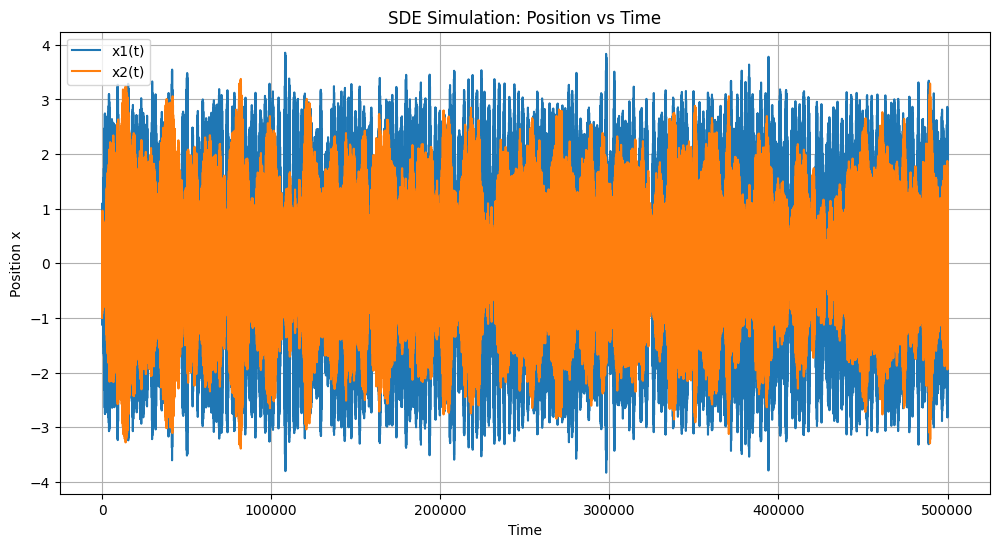

In [8]:
plt.figure(figsize=(12,  6))
plt.plot(sde_samples_x[:, 0], label='x1(t)')
plt.plot(sde_samples_x[:, 1], label='x2(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
def drift_QP_fn(t, state, args):
    """
    Drift function for the RWA equations
    """
    Q1, P1, Q2, P2 = state  # Unpack all state variables
    
    # Calculate gradients of Hamiltonian for both oscillators
    dQ1dt =  jax.grad(Hamiltonian_coupled, 1)(Q1, P1, Q2, P2) - GAMMA1*Q1
    dP1dt = -jax.grad(Hamiltonian_coupled, 0)(Q1, P1, Q2, P2) - GAMMA1*P1
    dQ2dt =  jax.grad(Hamiltonian_coupled, 3)(Q1, P1, Q2, P2) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian_coupled, 2)(Q1, P1, Q2, P2) - GAMMA2*P2
    
    return jnp.array([dQ1dt, dP1dt, dQ2dt, dP2dt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations for two coupled oscillators.
    Returns a 4x4 matrix with noise terms for both oscillators.
    """
    # Noise strength for oscillator 1
    noise_strength_QP1 = jnp.sqrt(2*GAMMA1*k_B * T/(M1*w1**2))
    # Noise strength for oscillator 2  
    noise_strength_QP2 = jnp.sqrt(2*GAMMA2*k_B * T/(M2*w2**2))
    
    # Create 4x4 matrix for both oscillators [Q1, P1, Q2, P2]
    noise_matrix = jnp.zeros((4, 4))
    noise_matrix = noise_matrix.at[0:2, 0:2].set(noise_strength_QP1 * jnp.eye(2))  # First oscillator
    noise_matrix = noise_matrix.at[2:4, 2:4].set(noise_strength_QP2 * jnp.eye(2))  # Second oscillator
    return noise_matrix



In [10]:
w_shape = (4,)  # state is (Q, P)
brownian_motion_QP = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

y0_QP = jnp.array([1, 0, 1, 0])

terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion_QP))

saveat = diffrax.SaveAt(ts=ts_dim)

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
)
sde_samples_QP = solution_QP.ys



100.00%|##########| [06:05<00:00,  3.66s/%]


Text(0.5, 1.02, 'M1=1.0, M2=1.0, ω1=1.0, ω2=1.0, ωp1=2.0, ωp2=2.0, \nFp1=0.1, Fp2=0.0, Q1=100.0, Q2=100.0, γ1=0.01, γ2=0.0, c=0.01, T=0.3')

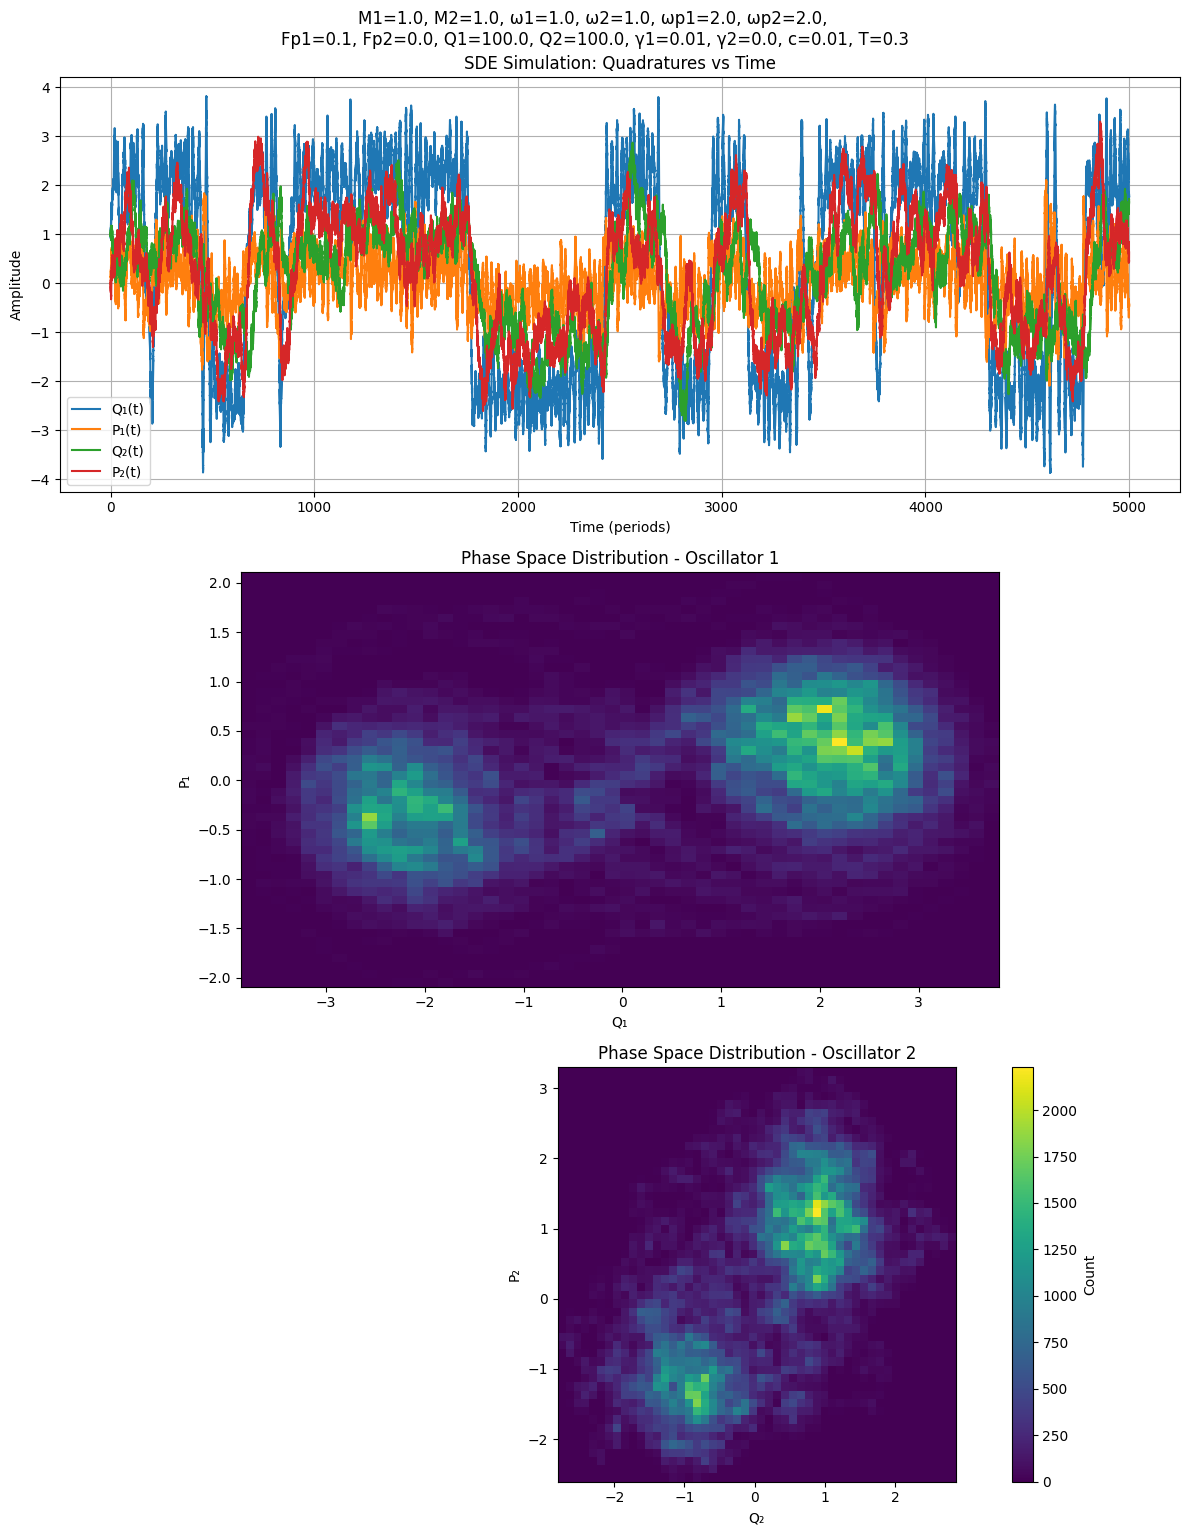

In [16]:
# Create a figure with three subplots vertically
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# Calculate decoherence time and use it for sampling
decoherence_time = 2 * Q1 / w1  # Using parameters of first oscillator
dt = ts_dim[1] - ts_dim[0]
sample_step = int(decoherence_time / dt)  # Use this for thinning the data
sample_step = 1

# Top subplot: Q(t) and P(t) trajectories with thinned samples
ax1.plot(ts_dim[::sample_step]/period, sde_samples_QP[::sample_step, 0], label='Q₁(t)')
ax1.plot(ts_dim[::sample_step]/period, sde_samples_QP[::sample_step, 1], label='P₁(t)')
ax1.plot(ts_dim[::sample_step]/period, sde_samples_QP[::sample_step, 2], label='Q₂(t)')
ax1.plot(ts_dim[::sample_step]/period, sde_samples_QP[::sample_step, 3], label='P₂(t)')
ax1.set_xlabel('Time (periods)')
ax1.set_ylabel('Amplitude')
ax1.set_title('SDE Simulation: Quadratures vs Time')
ax1.grid(True)
ax1.legend()

# Middle subplot: Histogram for first oscillator (using thinned samples)
ax2.hist2d(sde_samples_QP[::sample_step, 0], sde_samples_QP[::sample_step, 1], 
           bins=50, cmap='viridis')
ax2.set_xlabel('Q₁')
ax2.set_ylabel('P₁')
ax2.set_title('Phase Space Distribution - Oscillator 1')
ax2.set_aspect('equal')

# Bottom subplot: Histogram for second oscillator (using thinned samples)
hist = ax3.hist2d(sde_samples_QP[::sample_step, 2], sde_samples_QP[::sample_step, 3], 
                  bins=50, cmap='viridis')
ax3.set_xlabel('Q₂')
ax3.set_ylabel('P₂')
ax3.set_title('Phase Space Distribution - Oscillator 2')
ax3.set_aspect('equal')

# Add colorbar
plt.colorbar(hist[3], ax=ax3, label='Count')

plt.tight_layout()

# Add overall title with parameters
title = (f'M1={M1}, M2={M2}, ω1={w1}, ω2={w2}, ωp1={wp1}, ωp2={wp2}, \n'
        f'Fp1={Fp1}, Fp2={Fp2}, Q1={Q1}, Q2={Q2}, γ1={gamma1}, γ2={gamma2}, c={c}, T={T}')
fig.suptitle(title, wrap=True, y=1.02)

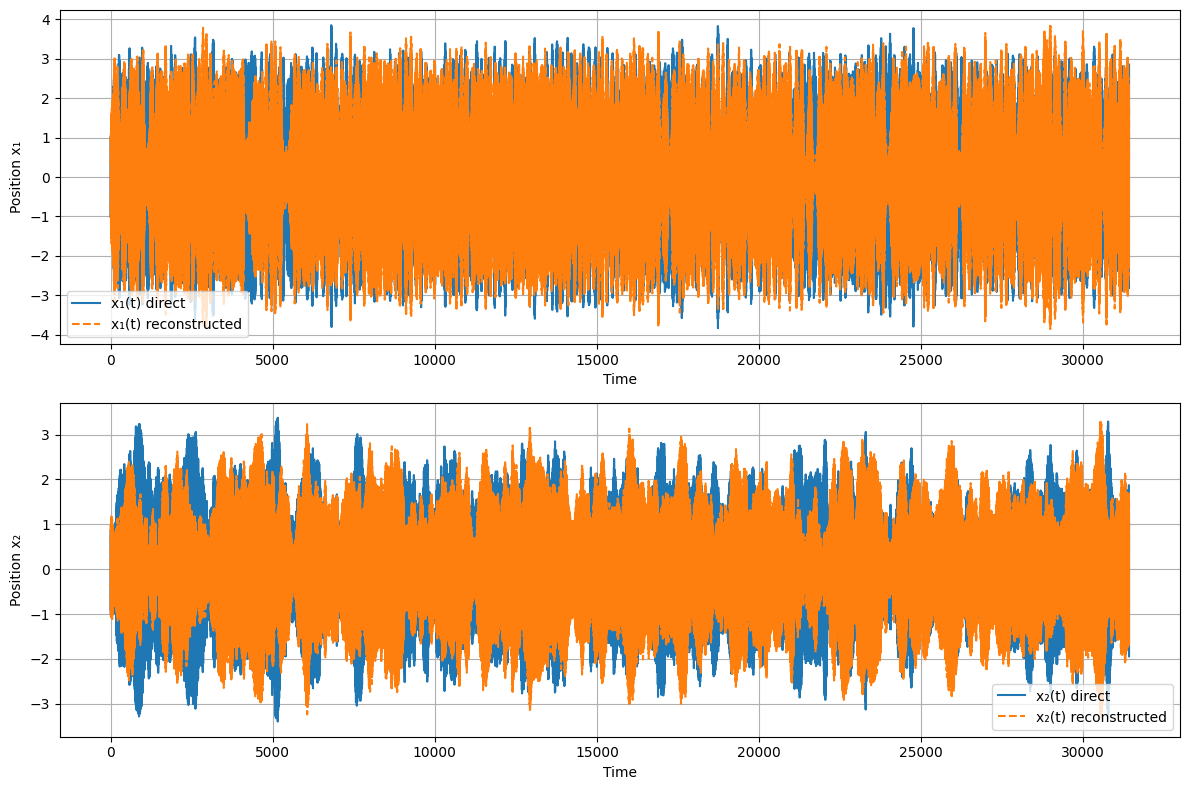

In [12]:
def reconstruct_x(t, Q1, P1, Q2, P2):
    """
    Reconstruct x(t) from Q(t) and P(t) for both oscillators.
    
    Args:
        t: time array
        Q1, P1: quadratures for first oscillator
        Q2, P2: quadratures for second oscillator
    
    Returns:
        Tuple of (x1, x2) reconstructed positions
    """
    x1 = Q1 * jnp.cos(w1 * t) + P1 * jnp.sin(w1 * t)
    x2 = Q2 * jnp.cos(w2 * t) + P2 * jnp.sin(w2 * t)
    return x1, x2

id_start = 0
id_end = -1


# ... existing code ...

x1_direct = sde_samples_x[id_start:id_end, 0]  # First oscillator
x2_direct = sde_samples_x[id_start:id_end, 1]  # Second oscillator

# Get both reconstructed signals
x1_reconstructed, x2_reconstructed = reconstruct_x(
    ts_dim[id_start:id_end], 
    sde_samples_QP[id_start:id_end, 0],  # Q1
    sde_samples_QP[id_start:id_end, 1],  # P1
    sde_samples_QP[id_start:id_end, 2],  # Q2
    sde_samples_QP[id_start:id_end, 3]   # P2
)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot first oscillator
ax1.plot(ts_dim[id_start:id_end], x1_direct, label='x₁(t) direct')
ax1.plot(ts_dim[id_start:id_end], x1_reconstructed, '--', label='x₁(t) reconstructed')
ax1.set_xlabel('Time')
ax1.set_ylabel('Position x₁')
ax1.grid(True)
ax1.legend()

# Plot second oscillator
ax2.plot(ts_dim[id_start:id_end], x2_direct, label='x₂(t) direct')
ax2.plot(ts_dim[id_start:id_end], x2_reconstructed, '--', label='x₂(t) reconstructed')
ax2.set_xlabel('Time')
ax2.set_ylabel('Position x₂')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
relaxation_time = 2 * Q1 / w1
dt = ts_dim[1] - ts_dim[0]  # time step in the simulation
step = int(relaxation_time / dt)

JIT session error: Cannot allocate memory


XlaRuntimeError: NOT_FOUND: Symbol main.4 not found.

In [17]:
# Calculate statistics for both oscillators
mean_direct_1 = []
mean_direct_2 = []
std_direct_1 = []
std_direct_2 = []
mean_reconstructed_1 = []
mean_reconstructed_2 = []
std_reconstructed_1 = []
std_reconstructed_2 = []

# Calculate step size based on w1 and Q1 (using first oscillator parameters)
relaxation_time = 2 * Q1 / w1
dt = ts_dim[1] - ts_dim[0]  # time step in the simulation
step = int(relaxation_time / dt)

for i in range(0, len(ts_dim), step):
    # Compute statistics for first oscillator
    mean_direct_1.append(jnp.mean(x1_direct[:i]))
    std_direct_1.append(jnp.std(x1_direct[:i]))
    mean_reconstructed_1.append(jnp.mean(x1_reconstructed[:i]))
    std_reconstructed_1.append(jnp.std(x1_reconstructed[:i]))
    
    # Compute statistics for second oscillator
    mean_direct_2.append(jnp.mean(x2_direct[:i]))
    std_direct_2.append(jnp.std(x2_direct[:i]))
    mean_reconstructed_2.append(jnp.mean(x2_reconstructed[:i]))
    std_reconstructed_2.append(jnp.std(x2_reconstructed[:i]))

# Create figure with four subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot means for first oscillator
ax1.plot(ts_dim[::step], mean_direct_1, label='Direct Integration')
ax1.plot(ts_dim[::step], mean_reconstructed_1, '--', label='Reconstructed')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mean')
ax1.set_title('Mean Comparison - Oscillator 1')
ax1.grid(True)
ax1.legend()

# Plot means for second oscillator
ax2.plot(ts_dim[::step], mean_direct_2, label='Direct Integration')
ax2.plot(ts_dim[::step], mean_reconstructed_2, '--', label='Reconstructed')
ax2.set_xlabel('Time')
ax2.set_ylabel('Mean')
ax2.set_title('Mean Comparison - Oscillator 2')
ax2.grid(True)
ax2.legend()

# Plot standard deviations for first oscillator
ax3.plot(ts_dim[::step], std_direct_1, label='Direct Integration')
ax3.plot(ts_dim[::step], std_reconstructed_1, '--', label='Reconstructed')
# Add horizontal line at theoretical value if needed
# ax3.axhline(y=jnp.sqrt(k_B*T/M1), color='r', linestyle=':', label='√(2kbT/m₁ω₁²)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Standard Deviation')
ax3.set_title('Standard Deviation Comparison - Oscillator 1')
ax3.grid(True)
ax3.legend()

# Plot standard deviations for second oscillator
ax4.plot(ts_dim[::step], std_direct_2, label='Direct Integration')
ax4.plot(ts_dim[::step], std_reconstructed_2, '--', label='Reconstructed')
# Add horizontal line at theoretical value if needed
# ax4.axhline(y=jnp.sqrt(k_B*T/M2), color='r', linestyle=':', label='√(2kbT/m₂ω₂²)')
ax4.set_xlabel('Time')
ax4.set_ylabel('Standard Deviation')
ax4.set_title('Standard Deviation Comparison - Oscillator 2')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()

JIT session error: Cannot allocate memory


XlaRuntimeError: NOT_FOUND: Symbol main.10 not found.

In [13]:
# # Compute statistics for Q and P
# mean_Q = []
# mean_P = []
# std_Q = []
# std_P = []
# cov_QP = []
# step = 1000

# for i in range(0, len(ts_dim), step):
#     # Compute means and standard deviations
#     mean_Q.append(jnp.mean(sde_samples_QP[:i, 0]))
#     mean_P.append(jnp.mean(sde_samples_QP[:i, 1]))
#     std_Q.append(jnp.std(sde_samples_QP[:i, 0]))
#     std_P.append(jnp.std(sde_samples_QP[:i, 1]))
#     # Compute covariance
#     cov_QP.append(jnp.mean(sde_samples_QP[:i, 0] * sde_samples_QP[:i, 1]))

# # Create figure with three subplots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# # Plot means
# ax1.plot(ts_dim[::step], mean_Q, label='Q')
# ax1.plot(ts_dim[::step], mean_P, '--', label='P')
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Mean')
# ax1.set_title('Mean of Q and P')
# ax1.grid(True)
# ax1.legend()

# # Plot standard deviations
# ax2.plot(ts_dim[::step], std_Q, label='Q')
# ax2.plot(ts_dim[::step], std_P, '--', label='P')
# # Add horizontal line at theoretical value
# theoretical_std = jnp.sqrt(k_B*T/(M*w_0**2))
# ax2.axhline(y=theoretical_std, color='r', linestyle=':', label='√(kbT/mω₀²)')
# ax2.set_xlabel('Time')
# ax2.set_ylabel('Standard Deviation')
# ax2.set_title('Standard Deviation of Q and P')
# ax2.grid(True)
# ax2.legend()

# # Plot covariance
# ax3.plot(ts_dim[::step], cov_QP, label='Cov(Q,P)')
# ax3.axhline(y=0, color='r', linestyle=':', label='Expected value')
# ax3.set_xlabel('Time')
# ax3.set_ylabel('Covariance')
# ax3.set_title('Covariance between Q and P')
# ax3.grid(True)
# ax3.legend()

# plt.tight_layout()
# plt.show()